# 03 - Player Performance Analysis (Top 11 / All-Rounders)

Builds batting, bowling and all-rounder scores from ball-by-ball data to rank players. The scoring logic lives in [`src/player_stats.py`](../src/player_stats.py).

- **Batting score** = 0.6 x normalised runs + 0.4 x normalised strike rate
- **Bowling score** = 0.7 x normalised economy (inverted, lower economy is better) + 0.3 x normalised overs bowled
- **All-rounder score** = 0.5 x batting score + 0.5 x bowling score

**Input:** `data/processed/matches_c.csv`, `data/processed/deliveries_c.csv`

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.player_stats import build_batting_stats, build_bowling_stats, build_all_rounder_stats, top_n

sns.set_style('whitegrid')

## Load cleaned data

In [2]:
matches_c_df = pd.read_csv('../data/processed/matches_c.csv')
deliveries_c_df = pd.read_csv('../data/processed/deliveries_c.csv')

## Merge matches with deliveries
(Same merge as `02_merge_datasets.ipynb` — repeated here so this notebook can run standalone.)

In [3]:
merged_df = pd.merge(matches_c_df, deliveries_c_df, left_on='id', right_on='match_id', how='left')

## Batting stats

In [4]:
batsman = build_batting_stats(deliveries_c_df)
top_batsmen = top_n(batsman, 'batting_score', 10)
top_batsmen

,runs,balls,strike_rate,runs_norm,sr_norm,batting_score
batter,,,,,,
V Kohli,8014,6236,128.511867,1.000000,0.428373,0.771349
DA Warner,6567,4849,135.429986,0.819441,0.451433,0.672238
S Dhawan,6769,5483,123.454313,0.844647,0.411514,0.671394
RG Sharma,6630,5183,127.918194,0.827302,0.426394,0.666939
SK Raina,5536,4177,132.535312,0.690791,0.441784,0.591188
AB de Villiers,5181,3487,148.580442,0.646494,0.495268,0.586003
MS Dhoni,5243,3947,132.835065,0.654230,0.442784,0.569651
CH Gayle,4997,3516,142.121729,0.623534,0.473739,0.563616
RV Uthappa,4954,3927,126.152279,0.618168,0.420508,0.539104


C:\Users\HomePC\AppData\Local\Temp\ipykernel_2960\353525122.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_batsmen['batting_score'], y=top_batsmen.index, ax=ax, palette='viridis')


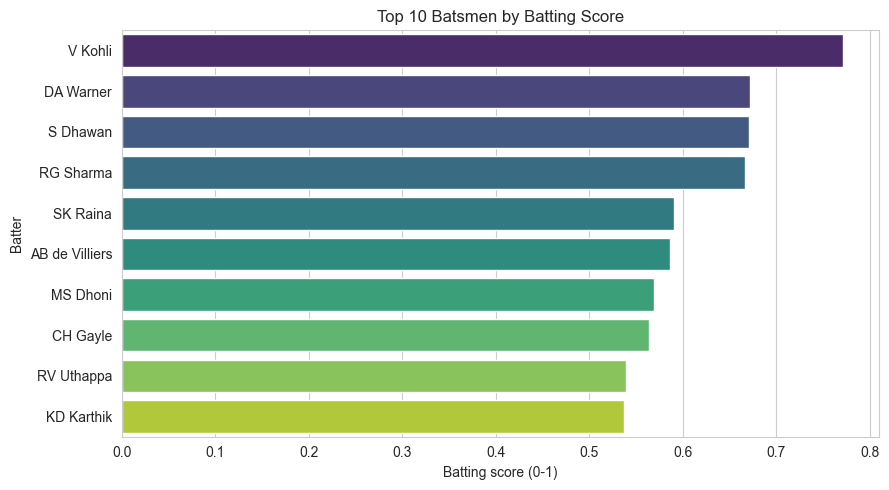

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top_batsmen['batting_score'], y=top_batsmen.index, ax=ax, palette='viridis')
ax.set_title('Top 10 Batsmen by Batting Score')
ax.set_xlabel('Batting score (0-1)')
ax.set_ylabel('Batter')
plt.tight_layout()
plt.savefig('../reports/figures/top_10_batsmen.png', dpi=150)
plt.show()

## Bowling stats

In [6]:
bowler = build_bowling_stats(deliveries_c_df)
top_bowlers = top_n(bowler, 'bowling_score', 10)
top_bowlers

,balls,runs_conceded,overs,economy,wickets,wickets_norm,econ_norm,bowling_score
bowler,,,,,,,,
R Ashwin,4679,5435,779.833333,6.969438,198.0,0.929577,0.806405,0.864483
SP Narine,4146,4672,691.000000,6.761216,200.0,0.938967,0.812188,0.834351
B Kumar,4060,5051,676.666667,7.464532,195.0,0.915493,0.792652,0.815160
RA Jadeja,3895,4917,649.166667,7.574326,169.0,0.793427,0.789602,0.802444
PP Chawla,3895,5179,649.166667,7.977920,201.0,0.943662,0.778391,0.794596
Harbhajan Singh,3496,4101,582.666667,7.038330,161.0,0.755869,0.804491,0.787278
YS Chahal,3628,4681,604.666667,7.741455,213.0,1.000000,0.784960,0.782071
A Mishra,3444,4193,574.000000,7.304878,183.0,0.859155,0.797087,0.778760
JJ Bumrah,3185,3840,530.833333,7.233909,182.0,0.854460,0.799058,0.763530


C:\Users\HomePC\AppData\Local\Temp\ipykernel_2960\3776763946.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bowlers['bowling_score'], y=top_bowlers.index, ax=ax, palette='mako')


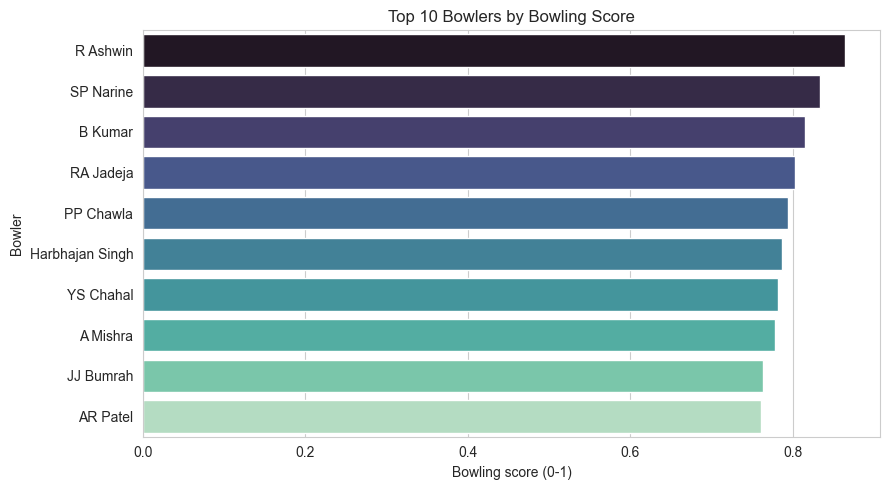

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top_bowlers['bowling_score'], y=top_bowlers.index, ax=ax, palette='mako')
ax.set_title('Top 10 Bowlers by Bowling Score')
ax.set_xlabel('Bowling score (0-1)')
ax.set_ylabel('Bowler')
plt.tight_layout()
plt.savefig('../reports/figures/top_10_bowlers.png', dpi=150)
plt.show()

## All-rounder stats
> **Note:** the original notebook rebuilt the `bowler` table with a plain dict midway through, which silently dropped the `wickets_norm` column computed just before it. `build_bowling_stats()` in `src/player_stats.py` joins wickets back onto the final table so that data isn't lost.

In [8]:
all_rounders = build_all_rounder_stats(deliveries_c_df)
top_all_rounders = top_n(all_rounders, 'ar_score', 10)
top_all_rounders

,runs,balls_x,strike_rate,runs_norm,sr_norm,batting_score,balls_y,runs_conceded,overs,economy,wickets,wickets_norm,econ_norm,bowling_score,ar_score
batter,,,,,,,,,,,,,,,
V Kohli,8014,6236,128.511867,1.000000,0.428373,0.771349,264,371,44.000000,8.431818,5.0,0.023474,0.765783,0.552914,0.662132
DA Warner,6567,4849,135.429986,0.819441,0.451433,0.672238,2,2,0.333333,6.000000,0.0,0.000000,0.833333,0.583397,0.627818
RG Sharma,6630,5183,127.918194,0.827302,0.426394,0.666939,349,462,58.166667,7.942693,16.0,0.075117,0.779370,0.567876,0.617407
SK Raina,5536,4177,132.535312,0.690791,0.441784,0.591188,930,1139,155.000000,7.348387,30.0,0.140845,0.795878,0.616691,0.603940
S Dhawan,6769,5483,123.454313,0.844647,0.411514,0.671394,49,72,8.166667,8.816327,4.0,0.018779,0.755102,0.531650,0.601522
RA Jadeja,2959,2378,124.432296,0.369229,0.414774,0.387447,3895,4917,649.166667,7.574326,169.0,0.793427,0.789602,0.802444,0.594945
SP Narine,1534,984,155.894309,0.191415,0.519648,0.322708,4146,4672,691.000000,6.761216,200.0,0.938967,0.812188,0.834351,0.578529
SR Watson,3880,2892,134.163209,0.484153,0.447211,0.469376,2137,2742,356.166667,7.698643,107.0,0.502347,0.786149,0.687286,0.578331
CH Gayle,4997,3516,142.121729,0.623534,0.473739,0.563616,584,755,97.333333,7.756849,19.0,0.089202,0.784532,0.586560,0.575088


C:\Users\HomePC\AppData\Local\Temp\ipykernel_2960\638537130.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_all_rounders['ar_score'], y=top_all_rounders.index, ax=ax, palette='rocket')


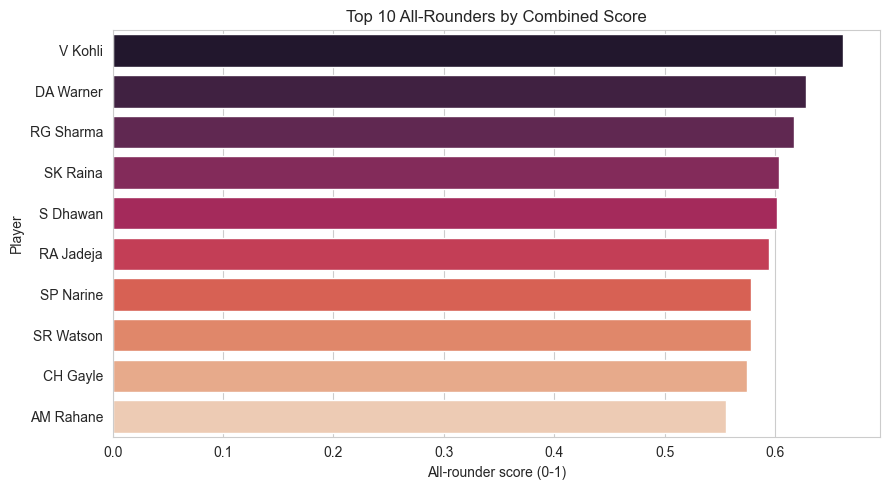

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top_all_rounders['ar_score'], y=top_all_rounders.index, ax=ax, palette='rocket')
ax.set_title('Top 10 All-Rounders by Combined Score')
ax.set_xlabel('All-rounder score (0-1)')
ax.set_ylabel('Player')
plt.tight_layout()
plt.savefig('../reports/figures/top_10_all_rounders.png', dpi=150)
plt.show()

## Bonus: economy vs. strike rate, at a glance

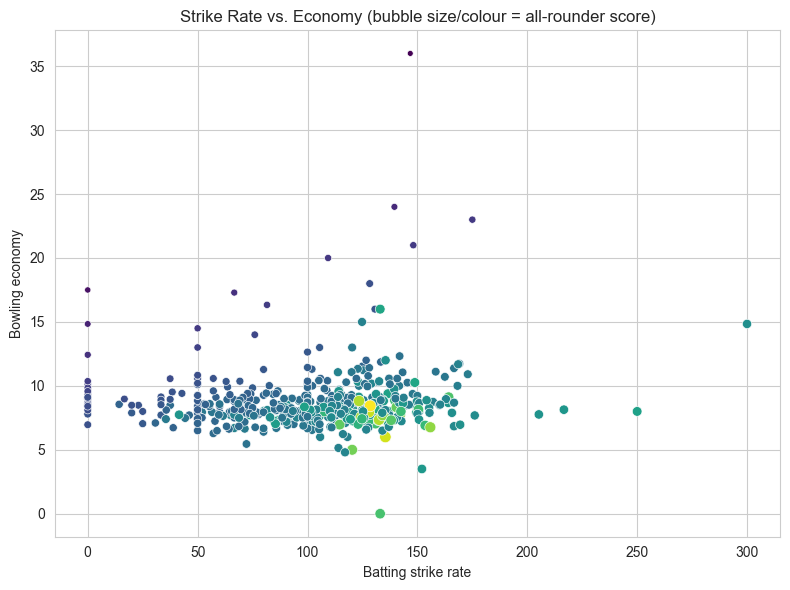

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    x=all_rounders['strike_rate'], y=all_rounders['economy'],
    size=all_rounders['ar_score'], hue=all_rounders['ar_score'],
    palette='viridis', legend=False, ax=ax,
)
ax.set_title('Strike Rate vs. Economy (bubble size/colour = all-rounder score)')
ax.set_xlabel('Batting strike rate')
ax.set_ylabel('Bowling economy')
plt.tight_layout()
plt.savefig('../reports/figures/strike_rate_vs_economy.png', dpi=150)
plt.show()